# Analyzing EC2 Instance Costs
Implementation of both parts of the supplied activity. Use the supplied CSV prices; these are dataset values, not current AWS quotes. Run cells from top to bottom.

Dependency setup: `python -m pip install pandas matplotlib seaborn scikit-learn jupyter`


## Part 1 Step 2 Load and explore


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'ec2dataset.csv'
data = pd.read_csv(file_path)
data.info()
print(data.head().to_string(index=False))
print('Dataset shape:', data.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 861 entries, 0 to 860
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Name                     861 non-null    object
 1   API Name                 861 non-null    object
 2   Instance Memory          861 non-null    object
 3   vCPUs                    861 non-null    object
 4   Instance Storage         861 non-null    object
 5   Network Performance      861 non-null    object
 6   On Demand                861 non-null    object
 7   Linux Reserved cost      861 non-null    object
 8   Linux Spot Minimum cost  861 non-null    object
 9   Windows On Demand cost   861 non-null    object
 10  Windows Reserved cost    861 non-null    object
dtypes: object(11)
memory usage: 74.1+ KB
     Name  API Name Instance Memory                                                                                                                  vCPUs Instance 

## Part 1 Step 3 Clean costs


In [2]:
cost_columns = ['On Demand', 'Linux Reserved cost',
                'Linux Spot Minimum cost', 'Windows On Demand cost',
                'Windows Reserved cost']

for column in cost_columns:
    data[column] = pd.to_numeric(
        data[column].str.replace('[$, hourly]', '', regex=True),
        errors='coerce'
    )

print('Missing values after cost conversion:')
print(data[cost_columns].isnull().sum())


Missing values after cost conversion:
On Demand                   20
Linux Reserved cost         24
Linux Spot Minimum cost     39
Windows On Demand cost     263
Windows Reserved cost      266
dtype: int64


## Part 1 Step 4 Summary statistics


In [3]:
cost_summary = data[cost_columns].describe()
print(cost_summary.to_string())


        On Demand  Linux Reserved cost  Linux Spot Minimum cost  Windows On Demand cost  Windows Reserved cost
count  841.000000           837.000000               822.000000              598.000000             595.000000
mean     5.188935             3.200449                 0.725993                8.561024               6.297091
std     22.728064            13.904896                 1.775821               30.135524              20.088637
min      0.004200             0.002600                 0.000700                0.008100               0.005900
25%      0.340000             0.215900                 0.103650                0.726900               0.588950
50%      1.563100             0.984800                 0.372600                3.196000               2.558300
75%      4.118000             2.635900                 0.949725                8.143250               6.371000
max    407.680000           251.230800                45.630200              448.896000             292.446800


## Part 1 Step 5 Cost boxplot


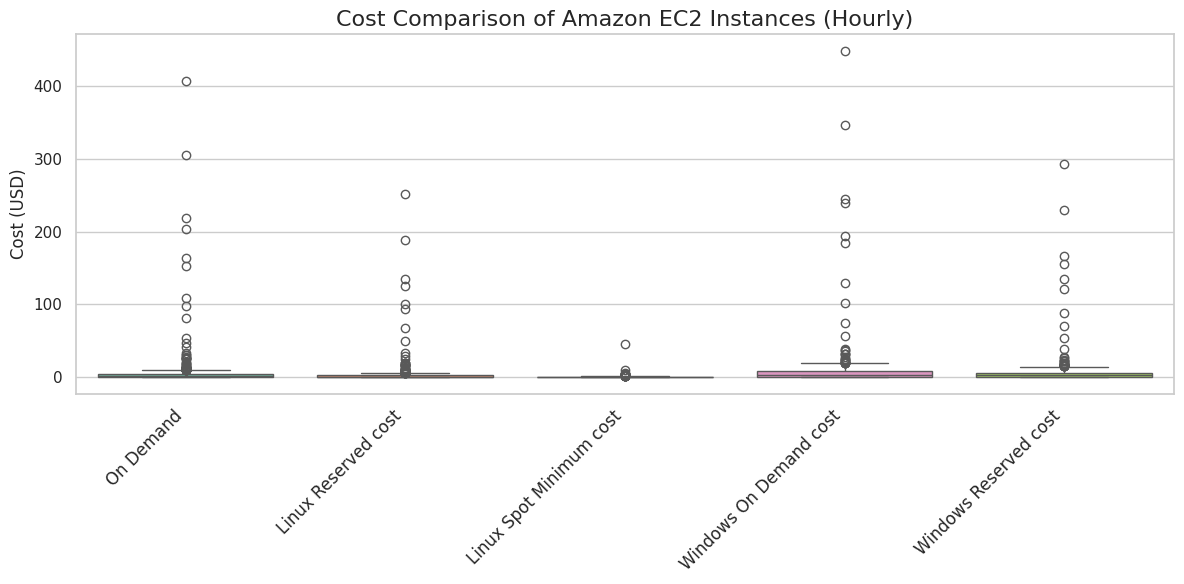

In [4]:
sns.set(style='whitegrid')
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[cost_columns], palette='Set2')
plt.title('Cost Comparison of Amazon EC2 Instances (Hourly)', fontsize=16)
plt.ylabel('Cost (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.show()


## Part 1 Step 6 IQR outliers


In [5]:
def detect_outliers(column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) |
                (data[column] > upper_bound)]

outliers_on_demand = detect_outliers('On Demand')
print(outliers_on_demand.to_string(index=False))
print('Number of On-Demand outliers:', len(outliers_on_demand))


                                         Name            API Name Instance Memory     vCPUs                                Instance Storage Network Performance  On Demand  Linux Reserved cost  Linux Spot Minimum cost  Windows On Demand cost  Windows Reserved cost
                               C7A Metal-48xl      c7a.metal-48xl       384.0 GiB 192 vCPUs                                        EBS only          50 Gigabit     9.8534               6.5180                   1.4675                 18.6854                15.3500
                                 C7A 48xlarge        c7a.48xlarge       384.0 GiB 192 vCPUs                                        EBS only          50 Gigabit     9.8534               6.5180                   2.7641                 18.6854                15.3500
                               X2IDN 24xlarge      x2idn.24xlarge      1536.0 GiB  96 vCPUs  2850 GB                 (2 * 1425 GB NVMe SSD)          75 Gigabit    10.0035               6.1551                 

## Part 1 Step 7 Compare reserved and On-Demand


In [6]:
cost_comparison = (
    data[['Name', 'On Demand', 'Linux Reserved cost']]
    .dropna().sort_values('On Demand')
)
print(cost_comparison.head(10).to_string(index=False))

# Calculate savings to answer the question in Step 7.
cost_comparison['Hourly savings'] = (
    cost_comparison['On Demand'] - cost_comparison['Linux Reserved cost']
)
cost_comparison['Savings percent'] = (
    cost_comparison['Hourly savings'] / cost_comparison['On Demand'] * 100
)
print(cost_comparison.head(10).to_string(index=False))


     Name  On Demand  Linux Reserved cost
 T4G Nano     0.0042               0.0026
 T3A Nano     0.0047               0.0029
  T3 Nano     0.0052               0.0033
  T2 Nano     0.0058               0.0036
T4G Micro     0.0084               0.0053
T3A Micro     0.0094               0.0059
 T3 Micro     0.0104               0.0065
 T2 Micro     0.0116               0.0072
T4G Small     0.0168               0.0105
T3A Small     0.0188               0.0118
     Name  On Demand  Linux Reserved cost  Hourly savings  Savings percent
 T4G Nano     0.0042               0.0026          0.0016        38.095238
 T3A Nano     0.0047               0.0029          0.0018        38.297872
  T3 Nano     0.0052               0.0033          0.0019        36.538462
  T2 Nano     0.0058               0.0036          0.0022        37.931034
T4G Micro     0.0084               0.0053          0.0031        36.904762
T3A Micro     0.0094               0.0059          0.0035        37.234043
 T3 Micro    

## Part 1 Step 8 Filter families and summarize


In [7]:
def filter_instance_family(family):
    # Match the first word exactly, so T3 does not also include T3A.
    return data[data['Name'].str.split().str[0] == family]

t2_instances = filter_instance_family('T2')
t3_instances = filter_instance_family('T3')

t2_summary = t2_instances[cost_columns].describe()
t3_summary = t3_instances[cost_columns].describe()
print('T2 rows:', len(t2_instances), 'T3 rows:', len(t3_instances))
print('T2 Instance Costs Summary:\n', t2_summary.to_string())
print('\nT3 Instance Costs Summary:\n', t3_summary.to_string())


T2 rows: 7 T3 rows: 7
T2 Instance Costs Summary:
        On Demand  Linux Reserved cost  Linux Spot Minimum cost  Windows On Demand cost  Windows Reserved cost
count    7.00000             7.000000                 6.000000                7.000000               7.000000
mean     0.10520             0.065200                 0.026233                0.128757               0.088786
std      0.13306             0.082432                 0.023299                0.154409               0.103796
min      0.00580             0.003600                 0.001900                0.008100               0.005900
25%      0.01730             0.010800                 0.008500                0.024100               0.017700
50%      0.04640             0.028700                 0.019950                0.064400               0.046700
75%      0.13920             0.086250                 0.046700                0.173700               0.120750
max      0.37120             0.230000                 0.055300        

## Part 1 Step 8 Family boxplots


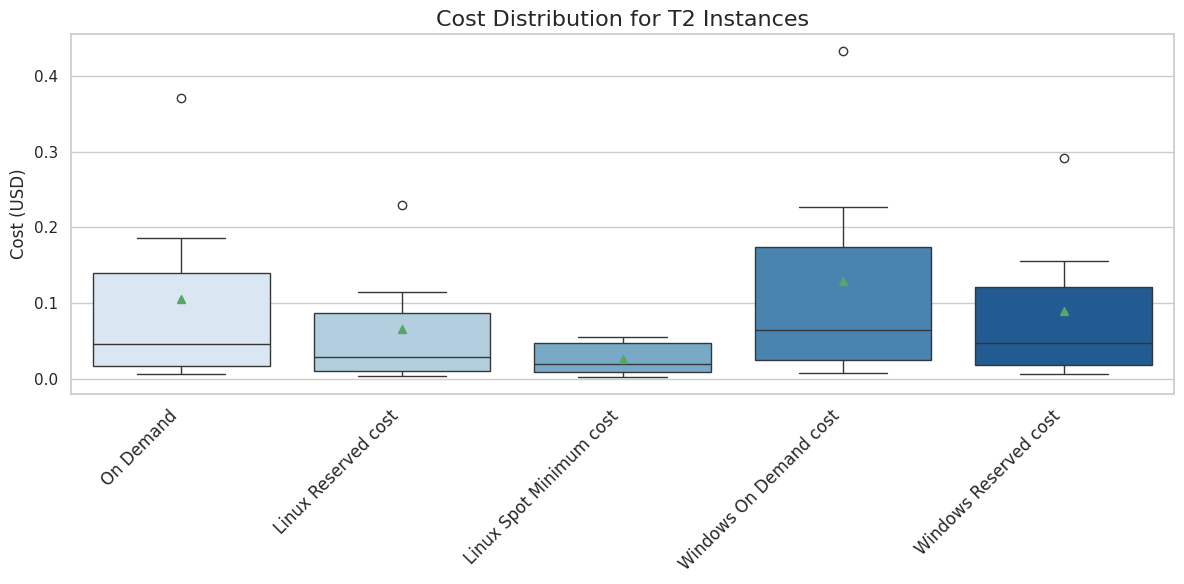

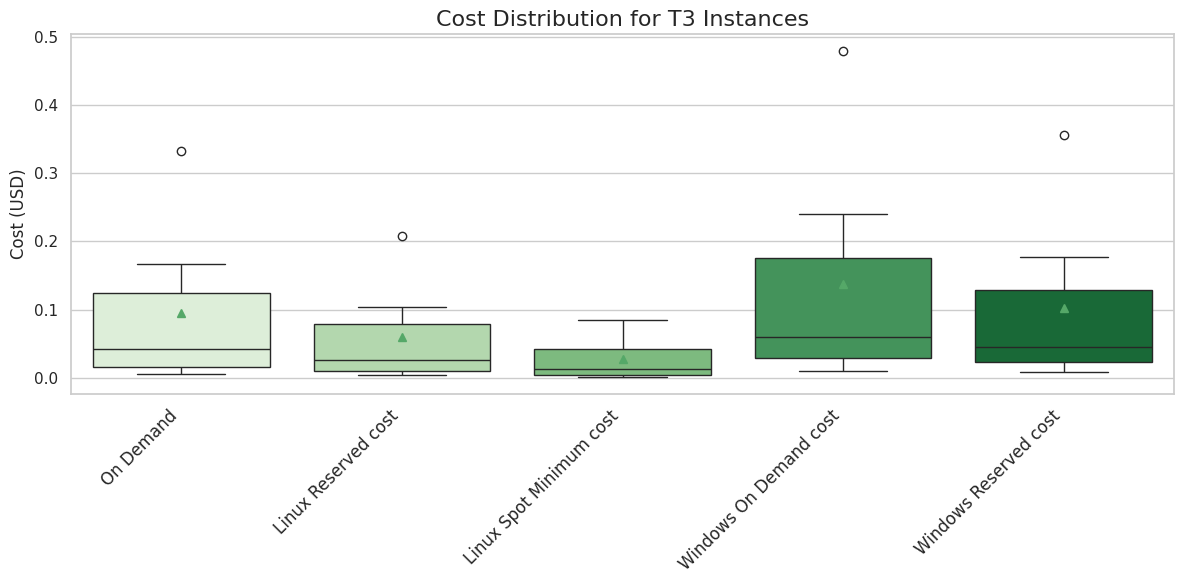

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=t2_instances[cost_columns], palette='Blues', showmeans=True)
plt.title('Cost Distribution for T2 Instances', fontsize=16)
plt.ylabel('Cost (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=t3_instances[cost_columns], palette='Greens', showmeans=True)
plt.title('Cost Distribution for T3 Instances', fontsize=16)
plt.ylabel('Cost (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.show()


## Part 1 Step 8 Family price comparison


In [9]:
comparison = pd.concat([
    t2_instances[['Name', 'On Demand', 'Linux Reserved cost']],
    t3_instances[['Name', 'On Demand', 'Linux Reserved cost']]
])
comparison_sorted = comparison.dropna().sort_values('On Demand')
print(comparison_sorted.head(10).to_string(index=False))


     Name  On Demand  Linux Reserved cost
  T3 Nano     0.0052               0.0033
  T2 Nano     0.0058               0.0036
 T3 Micro     0.0104               0.0065
 T2 Micro     0.0116               0.0072
 T3 Small     0.0208               0.0130
 T2 Small     0.0230               0.0144
T3 Medium     0.0416               0.0261
T2 Medium     0.0464               0.0287
 T3 Large     0.0832               0.0522
 T2 Large     0.0928               0.0575


## Part 2 Step 2 Reload and clean


In [10]:
# Reload so Part 2 can also be run independently.
data = pd.read_csv(file_path)
cost_columns = ['On Demand', 'Linux Reserved cost',
                'Linux Spot Minimum cost', 'Windows On Demand cost',
                'Windows Reserved cost']
for column in cost_columns:
    data[column] = pd.to_numeric(
        data[column].str.replace('[$, hourly]', '', regex=True),
        errors='coerce'
    )


## Part 2 Step 3 Convert features


In [11]:
data['Instance Memory'] = pd.to_numeric(
    data['Instance Memory'].str.replace(' GiB', '', regex=False)
)
data['vCPUs'] = pd.to_numeric(
    data['vCPUs'].str.extract(r'(\d+)', expand=False)
)
print(data[['Instance Memory', 'vCPUs']].head())


   Instance Memory  vCPUs
0              0.5      2
1              0.5      2
2              0.5      2
3              0.5      1
4              1.0      2


## Part 2 Step 4 Handle missing values


In [12]:
data_cleaned = data.dropna(
    subset=['On Demand', 'Instance Memory', 'vCPUs']
)
print(data_cleaned.isnull().sum())
print('Rows before cleaning:', len(data))
print('Rows available for regression:', len(data_cleaned))


Name                         0
API Name                     0
Instance Memory              0
vCPUs                        0
Instance Storage             0
Network Performance          0
On Demand                    0
Linux Reserved cost          4
Linux Spot Minimum cost     19
Windows On Demand cost     243
Windows Reserved cost      246
dtype: int64
Rows before cleaning: 861
Rows available for regression: 841


## Part 2 Step 5 Train test split


In [13]:
from sklearn.model_selection import train_test_split

X = data_cleaned[['Instance Memory', 'vCPUs']]
y = data_cleaned['On Demand']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training samples: {len(X_train)}, Testing samples: {len(X_test)}')


Training samples: 672, Testing samples: 169


## Part 2 Step 6 Train linear regression


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
print(f'Intercept: {model.intercept_}')
print(f'Coefficients: {model.coef_}')
print('Coefficient order: Instance Memory, vCPUs')


Intercept: -0.482966595443342
Coefficients: [0.01002807 0.02175741]
Coefficient order: Instance Memory, vCPUs


## Part 2 Step 7 Evaluate


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')


Mean Absolute Error (MAE): 1.8132850149757658
Mean Squared Error (MSE): 26.939493665051216
Root Mean Squared Error (RMSE): 5.190326932385976


## Part 2 Step 8 Actual versus predicted plot


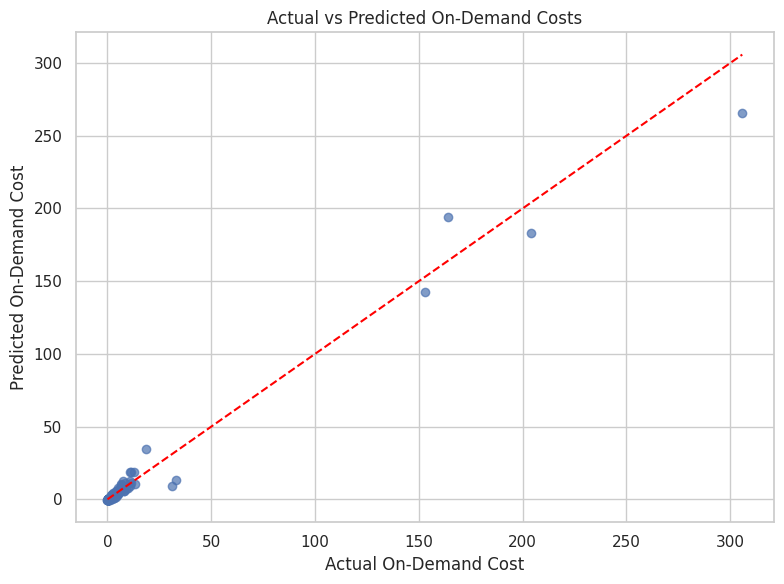

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='b')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],
         color='red', linestyle='--')
plt.title('Actual vs Predicted On-Demand Costs')
plt.xlabel('Actual On-Demand Cost')
plt.ylabel('Predicted On-Demand Cost')
plt.tight_layout()
plt.show()


## Part 2 Step 9 New prediction


In [17]:
# Same example as the handout, with feature names to avoid a warning.
new_instance = pd.DataFrame([[4, 2]], columns=X.columns)
predicted_cost = model.predict(new_instance)
print(f'Predicted On-Demand Cost for 4 GiB, 2 vCPUs: ${predicted_cost[0]:.4f}')


Predicted On-Demand Cost for 4 GiB, 2 vCPUs: $-0.3993
